In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/bobbyscience/league-of-legends-diamond-ranked-games-10-min/high_diamond_ranked_10min.csv


## 1. Kütüphaneler
Projede kullanacağımız araçları yüklüyoruz.
- pandas: Tablo verisiyle çalışmak için
- numpy: Matematik işlemleri için
- matplotlib & seaborn: Grafik çizmek için

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Dosya Yolu Bulma
Kaggle'da veri setinin tam yolunu bulmak için klasörleri listeliyoruz.

In [3]:
import os
for root, dirs, files in os.walk('/kaggle/input/'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/bobbyscience/league-of-legends-diamond-ranked-games-10-min/high_diamond_ranked_10min.csv


## 3. Veriyi Yükleme ve İlk İnceleme
CSV dosyasını okuyup df adlı tabloya yüklüyoruz.
df.shape ile kaç satır kaç sütun olduğunu görüyoruz.
df.head() ile ilk 5 satırı inceliyoruz.

In [4]:
df = pd.read_csv('/kaggle/input/datasets/bobbyscience/league-of-legends-diamond-ranked-games-10-min/high_diamond_ranked_10min.csv')

print("Veri Seti Boyutu:", df.shape)
df.head()

Veri Seti Boyutu: (9879, 40)


,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,...,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,...,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,...,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,...,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,...,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4


## 4. Sütun İsimleri
Veri setindeki tüm sütunları listeliyoruz.

Neden bakıyoruz?
- Veriyi tanımak için: 38 sütun var, neyle çalıştığımızı bilmemiz lazım
- X ve y'yi doğru ayırmak için: hangi sütun hedef, hangiler özellik?
- Hata önlemek için: sütun adını yanlış yazsak kod hata verir

blue... = Mavi takım istatistikleri
red... = Kırmızı takım istatistikleri
blueWins = Tahmin etmek istediğimiz hedef (1=kazandı, 0=kaybetti)

In [5]:
print("Sütun İsimleri:\n", df.columns.tolist())

Sütun İsimleri:
 ['gameId', 'blueWins', 'blueWardsPlaced', 'blueWardsDestroyed', 'blueFirstBlood', 'blueKills', 'blueDeaths', 'blueAssists', 'blueEliteMonsters', 'blueDragons', 'blueHeralds', 'blueTowersDestroyed', 'blueTotalGold', 'blueAvgLevel', 'blueTotalExperience', 'blueTotalMinionsKilled', 'blueTotalJungleMinionsKilled', 'blueGoldDiff', 'blueExperienceDiff', 'blueCSPerMin', 'blueGoldPerMin', 'redWardsPlaced', 'redWardsDestroyed', 'redFirstBlood', 'redKills', 'redDeaths', 'redAssists', 'redEliteMonsters', 'redDragons', 'redHeralds', 'redTowersDestroyed', 'redTotalGold', 'redAvgLevel', 'redTotalExperience', 'redTotalMinionsKilled', 'redTotalJungleMinionsKilled', 'redGoldDiff', 'redExperienceDiff', 'redCSPerMin', 'redGoldPerMin']


## 5. Eksik Değer Kontrolü
Her sütunda boş hücre var mı kontrol ediyoruz.
Model boş veriyle çalışamaz, eksik varsa doldurmak veya silmek gerekir.
Sonuç: 0 eksik değer, temiz veri!

In [6]:
print("Eksik Değer Sayısı:")
print(df.isnull().sum())

Eksik Değer Sayısı:
gameId                          0
blueWins                        0
blueWardsPlaced                 0
blueWardsDestroyed              0
blueFirstBlood                  0
blueKills                       0
blueDeaths                      0
blueAssists                     0
blueEliteMonsters               0
blueDragons                     0
blueHeralds                     0
blueTowersDestroyed             0
blueTotalGold                   0
blueAvgLevel                    0
blueTotalExperience             0
blueTotalMinionsKilled          0
blueTotalJungleMinionsKilled    0
blueGoldDiff                    0
blueExperienceDiff              0
blueCSPerMin                    0
blueGoldPerMin                  0
redWardsPlaced                  0
redWardsDestroyed               0
redFirstBlood                   0
redKills                        0
redDeaths                       0
redAssists                      0
redEliteMonsters                0
redDragons                  

## 6. Hedef Değişken Dağılımı
blueWins sütununda 0 ve 1 kaçar tane var sayıyoruz.
Veri dengeli mi değil mi görüyoruz.
Dengeli veri = SMOTE gibi yöntemlere gerek yok.

Kazanma Dağılımı:
blueWins
0    4949
1    4930
Name: count, dtype: int64


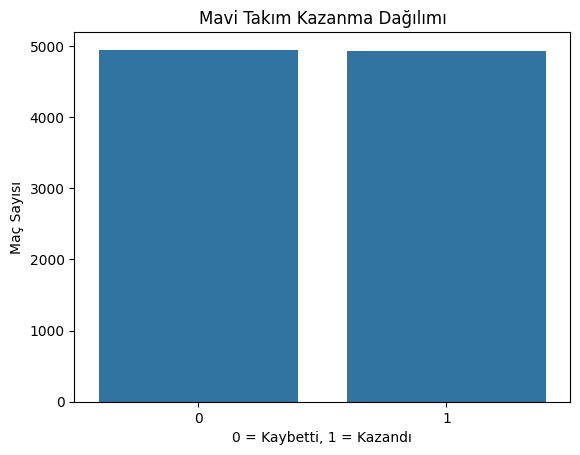

In [7]:
print("Kazanma Dağılımı:")
print(df['blueWins'].value_counts())

sns.countplot(x='blueWins', data=df)
plt.title('Mavi Takım Kazanma Dağılımı')
plt.xlabel('0 = Kaybetti, 1 = Kazandı')
plt.ylabel('Maç Sayısı')
plt.show()

## 7. Gereksiz Sütun Silme
gameId sadece maç numarası, kazanmayla ilgisi yok.
Model bu sütunu görürse yanlış öğrenebilir, siliyoruz.

In [8]:
df = df.drop('gameId', axis=1)

## 8. X ve y Ayırma
X = Modele verdiğimiz bilgiler (tüm istatistikler)
y = Modelin tahmin etmesi gereken şey (blueWins)
Modele diyoruz ki: "X'e bakarak y'yi tahmin etmeyi öğren!"

In [9]:
X = df.drop('blueWins', axis=1)
y = df['blueWins']

print("X boyutu:", X.shape)
print("y boyutu:", y.shape)

X boyutu: (9879, 38)
y boyutu: (9879,)


## 9. Train-Test Split
Veriyi eğitim (%80) ve test (%20) olarak ikiye bölüyoruz.
Eğitim: Model bunlarla öğrenir (7,903 maç)
Test: Model bunlarla sınanır, hiç görmemiştir (1,976 maç)
random_state=42: Her çalıştırmada aynı bölme yapılsın diye

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu:", X_test.shape)

Eğitim seti boyutu: (7903, 38)
Test seti boyutu: (1976, 38)


## 10. Model Karşılaştırma (Cross Validation)
3 farklı algoritma 5-fold cross validation ile karşılaştırılıyor.
Her model 5 farklı şekilde eğitilip test ediliyor, ortalaması alınıyor.



In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

modeller = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

for isim, model in modeller.items():
    skorlar = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{isim}: {skorlar.mean():.2f}")

Decision Tree: 0.64
Random Forest: 0.72
XGBoost: 0.70


## 11. Hiperparametre Optimizasyonu
XGBoost'un en iyi parametrelerini bulmak için RandomizedSearchCV kullanıyoruz.
20 farklı parametre kombinasyonu deneniyor.
En iyi CV skoru: 0.73

In [12]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0]
}

xgb = XGBClassifier(random_state=42, eval_metric='logloss')

search = RandomizedSearchCV(xgb, params, n_iter=20, cv=5, random_state=42)
search.fit(X_train, y_train)

print("En iyi parametreler:", search.best_params_)
print("En iyi CV skoru:", round(search.best_score_, 2))

En iyi parametreler: {'subsample': 0.6, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01}
En iyi CV skoru: 0.73


## 12. Test Seti Değerlendirmesi
Optimize edilmiş XGBoost modeli test setinde deneniyor.
Accuracy: %72
Precision, Recall, F1 skorları inceleniyor.

In [13]:
from sklearn.metrics import accuracy_score, classification_report

best_model = search.best_estimator_

y_pred = best_model.predict(X_test)

print("Test Dogruluğu:", round(accuracy_score(y_test, y_pred), 2))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Dogruluğu: 0.72

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.73      0.73       983
           1       0.73      0.71      0.72       993

    accuracy                           0.72      1976
   macro avg       0.72      0.72      0.72      1976
weighted avg       0.72      0.72      0.72      1976



## 13. Feature Importance Tablosu
En önemli 10 özelliği tablo olarak görüyoruz.
Hangi istatistik kazanmayı en çok etkiliyor?
- redGoldDiff: 0.31 → Altın farkı açık ara birinci
- blueGoldDiff: 0.18 → İkinci sırada yine altın
- Ejderha ve kill atmak çok daha düşük sırada

In [14]:
import pandas as pd

feature_importance = pd.DataFrame({
    'ozellik': X.columns,
    'onem': best_model.feature_importances_
}).sort_values('onem', ascending=False)

print(feature_importance.head(10))

                         ozellik      onem
34                   redGoldDiff  0.310326
15                  blueGoldDiff  0.184543
35             redExperienceDiff  0.049640
16            blueExperienceDiff  0.035344
7                    blueDragons  0.022387
25              redEliteMonsters  0.021000
6              blueEliteMonsters  0.020755
26                    redDragons  0.020360
14  blueTotalJungleMinionsKilled  0.018118
31            redTotalExperience  0.017148


## 14. Feature Importance
Hangi istatistik kazanmayı en çok etkiliyor? redGoldDiff: %31 → Altın farkı en önemli faktör! Ejderha ve kill atmak altın kadar etkili değil.

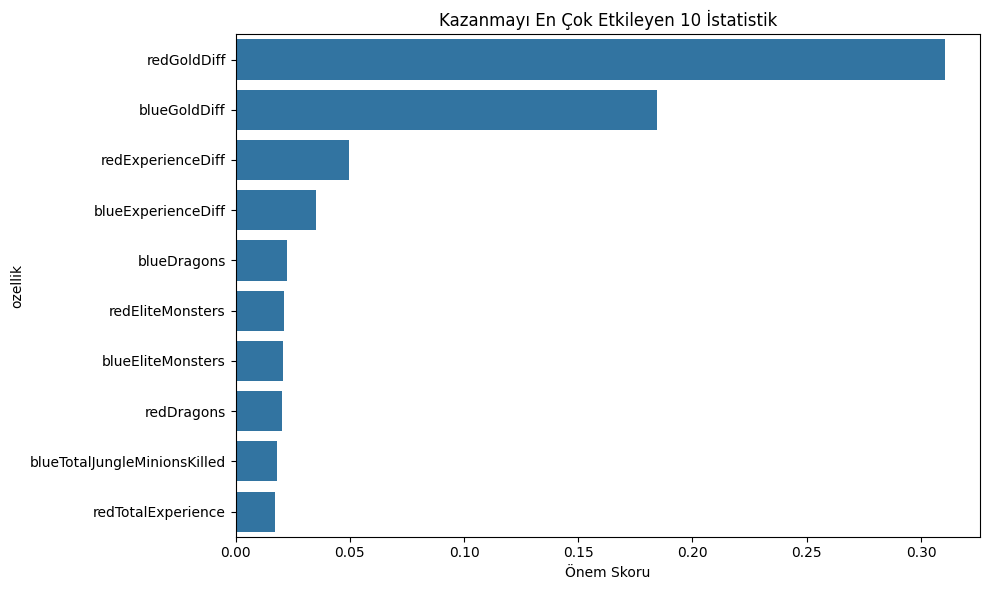

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(x='onem', y='ozellik', data=feature_importance.head(10))
plt.title('Kazanmayı En Çok Etkileyen 10 İstatistik')
plt.xlabel('Önem Skoru')
plt.tight_layout()
plt.show()

## 13. Confusion Matrix
Modelin doğru ve yanlış tahminlerini görselleştiriyoruz.
- Sol üst + sağ alt = Doğru tahminler (sarı)
- Sağ üst + sol alt = Yanlış tahminler (koyu)

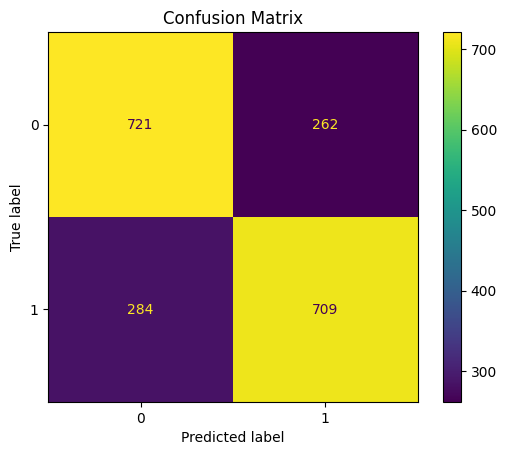

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title('Confusion Matrix')
plt.show()

## 14. ROC Curve
Modelin performansını eğri olarak gösteriyoruz.
AUC = 0.81 → İyi bir model (0.5 rastgele, 1.0 mükemmel)
Eğri sol üst köşeye ne kadar yakınsa model o kadar iyi.

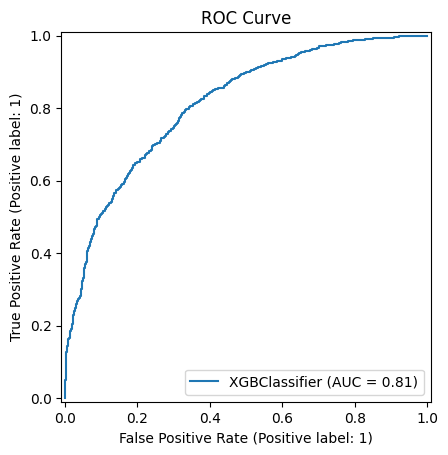

In [17]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title('ROC Curve')
plt.show()

## 16. Kazanma Şansı Analizi
"Şunu yaparsan kazanma şansın şu kadar artar" analizini yapıyoruz.
Ortalama bir maç alıp tek değişkeni değiştirerek etkisini ölçüyoruz.
predict_proba: Modelin yüzde olarak tahmin olasılığını verir.

In [18]:
import numpy as np

ortalama_mac = X_test.mean()

temel_sans = best_model.predict_proba([ortalama_mac])[0][1]
print(f"Ortalama bir maçta kazanma şansı: %{round(temel_sans*100, 1)}")

ejderha_mac = ortalama_mac.copy()
ejderha_mac['blueDragons'] += 1
ejderha_sans = best_model.predict_proba([ejderha_mac])[0][1]
print(f"1 ejderha alınca: %{round(ejderha_sans*100, 1)} (fark: +%{round((ejderha_sans-temel_sans)*100, 1)})")

altin_mac = ortalama_mac.copy()
altin_mac['blueGoldDiff'] += 500
altin_sans = best_model.predict_proba([altin_mac])[0][1]
print(f"500 altın önde olunca: %{round(altin_sans*100, 1)} (fark: +%{round((altin_sans-temel_sans)*100, 1)})")

Ortalama bir maçta kazanma şansı: %47.20000076293945
1 ejderha alınca: %49.79999923706055 (fark: +%2.5999999046325684)
500 altın önde olunca: %49.79999923706055 (fark: +%2.5999999046325684)


## 17. Senaryo Analizi
Farklı hamlelerin kazanma şansına etkisi karşılaştırılıyor.
3000 altın önde: +%9.7 en büyük etki
5 Kill önde: sadece +%0.2
Sonuç: Kill değil, altın kazanmak önemli!

In [19]:
senaryolar = {
    "1 Kule Yıkınca": ("blueTowersDestroyed", 1),
    "1 Ejderha Alınca": ("blueDragons", 1),
    "1000 Altın Önde": ("blueGoldDiff", 1000),
    "3000 Altın Önde": ("blueGoldDiff", 3000),
    "5 Kill Önde": ("blueKills", 5),
    "İlk Kan": ("blueFirstBlood", 1),
}

for senaryo, (ozellik, deger) in senaryolar.items():
    mac = ortalama_mac.copy()
    mac[ozellik] += deger
    sans = best_model.predict_proba([mac])[0][1]
    fark = (sans - temel_sans) * 100
    print(f"{senaryo}: %{round(sans*100, 1)} (fark: +%{round(fark, 1)})")

1 Kule Yıkınca: %47.20000076293945 (fark: +%0.0)
1 Ejderha Alınca: %49.79999923706055 (fark: +%2.5999999046325684)
1000 Altın Önde: %51.0 (fark: +%3.799999952316284)
3000 Altın Önde: %56.900001525878906 (fark: +%9.699999809265137)
5 Kill Önde: %47.400001525878906 (fark: +%0.20000000298023224)
İlk Kan: %47.400001525878906 (fark: +%0.20000000298023224)


## 18. Modeli Kaydetme
Eğitilmiş modeli pickle ile dosyaya kaydediyoruz.
Böylece her seferinde tekrar eğitmek zorunda kalmayız.
İleride yeni verilerle tahmin yapmak için yüklenebilir.

In [20]:
import pickle

with open('lol_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Model kaydedildi!")

Model kaydedildi!
